# Modeling Notebook

This model houses the baseline and simple models, in preparation for my final complex & tuned model using XGBoost. The final model will be housed in a separate notebook, where it will be deployed into a streamlit application.

## Overview

**Baseline Model:**

City Avg. Price

**Hypothesis:** 
- As City Avg. Price increases, price will increase.

- As Size of Home increases, price will increase.

- as city_te increases, price will increase.

**Simple Model:**

**Multi-Linear Regression:**

Using bed, bath, and city_te

**Hypothesis:**

- All features will increase price as features increase.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/cleaned_ny_listings.csv')
df.head()

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,postal_code,house_size,prev_sold_date,city_te
0,48310.0,for_sale,225000,4,2,0.24,871278.0,Copake,New York,12521.0,1239,2018-02-01,372566.93
1,32016.0,for_sale,375000,3,2,1.20,1427842.0,Millerton,New York,12546.0,1350,2018-08-31,298882.86
2,26779.0,for_sale,194900,4,3,1.29,1431678.0,Nassau,New York,12123.0,2274,NaN,259020.00
3,10211.0,for_sale,40000,2,1,0.20,1202236.0,Nassau,New York,12123.0,690,2005-12-01,259020.00
4,10368.0,for_sale,125000,3,2,1.00,1531619.0,Hoosick Falls,New York,12090.0,980,NaN,194095.79


In [6]:
# Data preparation for modeling
model_cols = ['price', 'bed', 'bath', 'city_te', 'city', 'house_size']
df_model = df[model_cols].dropna().copy()

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# One split used by both models
train_df, test_df = train_test_split(df_model, test_size=0.2, random_state=42)

***

# **Baseline Model: City Average Price**

In [7]:
# Baseline model: city average price
city_avg_train = train_df.groupby('city')['price'].mean()
global_avg_train = train_df['price'].mean()

baseline_pred = test_df['city'].map(city_avg_train).fillna(global_avg_train)

mae_baseline = mean_absolute_error(test_df['price'], baseline_pred)
mse_baseline = mean_squared_error(test_df['price'], baseline_pred)
rmse_baseline = np.sqrt(mse_baseline)
r2_baseline = r2_score(test_df['price'], baseline_pred)

print('Baseline Model Diagnostics:')
print(f'MAE: {mae_baseline:.2f}')
print(f'RMSE: {rmse_baseline:.2f}')
print(f'R2: {r2_baseline:.3f}')

Baseline Model Diagnostics:
MAE: 93888.91
RMSE: 134916.88
R2: 0.740


A very strong baseline, accounting for ~70% of the variability of price. Errors are high, but should be acceptable in the context scale of house prices.

***

# **Simple Model**

In [10]:
# Multicollinearity check (before simple model)
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

features = ['bed', 'bath', 'city_te']
X_vif = train_df[features].copy()

# Pairwise correlation matrix
print('Feature Correlation Matrix:')
print(X_vif.corr().round(3))

# Variance Inflation Factor (VIF)
X_vif_const = sm.add_constant(X_vif)
vif_df = pd.DataFrame({
    'feature': X_vif_const.columns,
    'VIF': [variance_inflation_factor(X_vif_const.values, i) for i in range(X_vif_const.shape[1])]
})

# Remove constant row for interpretation
vif_df = vif_df[vif_df['feature'] != 'const'].sort_values('VIF', ascending=False)

print('\nVIF Table:')
print(vif_df.to_string(index=False))

Feature Correlation Matrix:
           bed   bath  city_te
bed      1.000  0.396    0.060
bath     0.396  1.000    0.274
city_te  0.060  0.274    1.000

VIF Table:
feature      VIF
   bath 1.281164
    bed 1.189528
city_te 1.084183


### Multicollinearity check

VIF scores look good. For reference, common thresholds for concern are VIFs greater than 5 or 10.

In [13]:
# Simple model: multiple linear regression (with train/test validation split)
features = ['bed', 'bath', 'city_te']

X = df_model[features]
y = df_model['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

simple_pred = model.predict(X_test)

mae_simple = mean_absolute_error(y_test, simple_pred)
mse_simple = mean_squared_error(y_test, simple_pred)
rmse_simple = np.sqrt(mse_simple)
r2_simple = r2_score(y_test, simple_pred)

print('\nSimple Model Diagnostics:')
print(f'Train rows: {len(X_train)}, Test rows: {len(X_test)}')
print(f'MAE: {mae_simple:.2f}')
print(f'RMSE: {rmse_simple:.2f}')
print(f'R2: {r2_simple:.3f}')


Simple Model Diagnostics:
Train rows: 27696, Test rows: 6925
MAE: 88523.80
RMSE: 124339.64
R2: 0.779


# **Residual Checks**

Additional Simple Model Diagnostics:
Mean residual (bias): -3542.37
Residual std: 124298.15
Median absolute error: 64656.35
Corr(|residuals|, prediction): 0.375
Normality test p-value: 0.000000


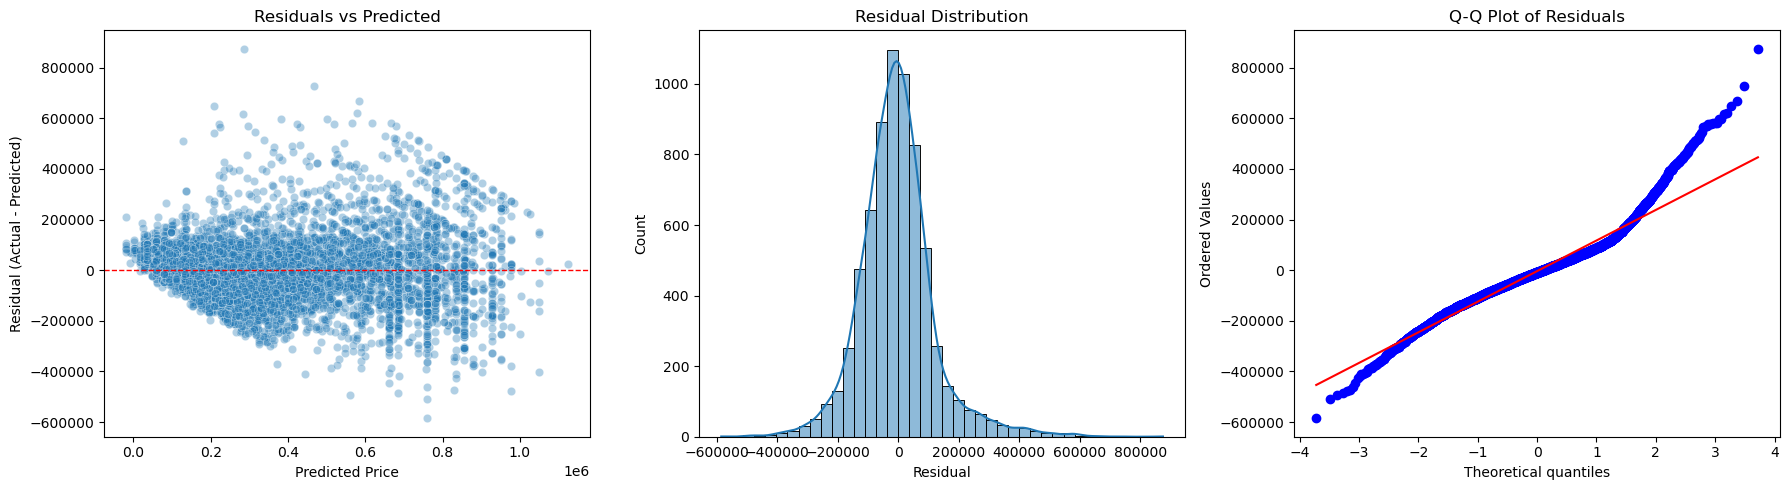

In [9]:
# Simple model diagnostics: residual checks
from scipy import stats

residuals = y_test - simple_pred

print('Additional Simple Model Diagnostics:')
print(f'Mean residual (bias): {residuals.mean():.2f}')
print(f'Residual std: {residuals.std():.2f}')
print(f'Median absolute error: {np.median(np.abs(residuals)):.2f}')
print(f'Corr(|residuals|, prediction): {np.corrcoef(np.abs(residuals), simple_pred)[0, 1]:.3f}')

# Normality check (D'Agostino and Pearson's test)
normality_stat, normality_p = stats.normaltest(residuals)
print(f'Normality test p-value: {normality_p:.6f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Residuals vs fitted values
sns.scatterplot(x=simple_pred, y=residuals, alpha=0.35, ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Residuals vs Predicted')
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residual (Actual - Predicted)')

# Residual distribution
sns.histplot(residuals, bins=40, kde=True, ax=axes[1])
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')

# Q-Q plot for residual normality
stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

## Interpretation
- The linear model is a reasonable baseline but violates key OLS assumptions (constant variance and normal residuals).

- Coefficient inference from plain OLS standard errors is less reliable.

- Predictive performance can still be acceptable, but uncertainty is not uniform across price ranges.

<br>

***

<br>

Overall, I expected these diagnostics for Multi-Linear Regression (MLR) to be poor, since this data is likely not linear and realistically messy. I anticipate that the XGBoost model will be much more robust than these original baseline models. 

However, these models were necessary to prove to ourselves that our model is actually performing well and providing valuable insight. The idea is that, if our final, tuned model cannot outperform the simple idea of guessing prices based on the average city price, then our model is not valuable at all.